# Loss Functions

The **loss function** turns "how wrong is the model?" into a single number we can minimize.
The optimizer (notebook `04_optimizers.ipynb`) then moves the parameters to reduce it, using
gradients from autograd (`03_autograd.ipynb`).

This notebook covers:
- **Regression losses**: MAE, MSE, RMSE, Huber — and how each reacts to outliers
- **Classification loss**: cross-entropy — the loss our language model uses
- How the choice of loss shapes what the model learns

In [5]:
# This notebook studies common loss functions used in machine learning models.
# We focus on regression losses first and then compare how different losses affect learning.
# - Mean Squared Error (MSE)
# - Mean Absolute Error (MAE)
# - Cross-Entropy Loss



import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# Sources:
# https://www.deeplearningbook.org/contents/ml.html
# https://arxiv.org/html/2504.04242v1
# https://medium.com/@chris.p.hughes10/a-brief-overview-of-cross-entropy-loss-523aa56b75d5


# Roadmap:
# 1. Introduction to Loss Functions
# 2. Loss Functions for Regression
# 3. Loss Functions for Classification
# 4. Effect of Loss Functions on Convergence
# 5. Choosing the Appropriate Loss Function

#### Introduction to Loss Functions
In machine learning, a loss function is a mathematical function that quantifies the difference between the predicted output of a model and the actual target values. It serves as a measure of how well the model is performing, and the goal of training a machine learning model is to minimize this loss function.
The loss function takes the predicted values from the model and the true target values as input and outputs a single scalar value that represents the error or discrepancy between the predictions and the actual values. The choice of loss function depends on the type of problem being solved (e.g., regression, classification) and the specific requirements of the model.
Common loss functions include:
- Mean Squared Error (MSE): Used for regression problems, it calculates the average of the squared differences between predicted and actual values.
- Cross-Entropy Loss: Used for classification problems, it measures the difference between the predicted probability distribution and the true distribution of the classes.
- Hinge Loss: Used for support vector machines (SVMs), it penalizes predictions that are on the wrong side of the decision boundary.
- Absolute Error: Used for regression problems, it calculates the average of the absolute differences between predicted and actual values.

The choice of loss function can significantly impact the training process and the performance of the model,as it guides the optimization algorithm in adjusting the model's parameters to minimize the error.

#### Loss Functions for Regression
##### Mean Absolute Error (MAE)
MAE is the average of the absolute differences between the predicted and actual values. It gives equal weight to all errors, making it a good choice when you want to treat all errors equally. The formula for MAE is:
 $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

##### Mean Squared Error (MSE)
MSE is the average of the squared differences between the predicted and actual values. It gives more weight to larger errors, making it a good choice when you want to penalize larger errors more heavily. The formula for MSE is:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

##### Root Mean Squared Error (RMSE)
RMSE is the square root of the mean squared error. It gives more weight to larger errors, similar to MSE, but is in the same units as the target variable, making it easier to interpret. The formula for RMSE is:
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$


##### Huber Loss
Huber behaves like **MSE for small errors** and like **MAE for large errors**, giving robustness to outliers while keeping a smooth gradient near zero. With threshold $\delta$:
$$L_\delta(e) = \begin{cases} \tfrac{1}{2}e^2 & |e|\le\delta \\ \delta\,(|e|-\tfrac{1}{2}\delta) & |e|>\delta \end{cases}, \qquad e = y-\hat{y}$$

##### Example: comparing regression losses with outliers
We fit the same linear regression model with three different training losses: MSE, MAE, and Huber.

The dataset contains a linear trend plus a few large outliers. This makes it easier to see the practical effect of each loss:
- MSE reacts strongly to large errors and tends to move toward the outliers.
- MAE is more robust because every error has the same weight.
- Huber behaves like MSE for small errors and like MAE for large errors.

RMSE is kept as an evaluation metric in the table below. It is not trained separately because minimizing RMSE leads to the same optimum as minimizing MSE.

In [15]:
# 2. Loss Functions for Regression

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + 1 + np.random.randn(100) * 5  # Linear relation with noise
#calculate losses for a simple linear model
y_pred = 2 * X.squeeze() + 1  # Perfect linear model without noise
print("MAE:", mae(y, y_pred))
print("MSE:", mse(y, y_pred))
print("RMSE:", rmse(y, y_pred))

MAE: 4.31192299714378
MSE: 25.744043102686852
RMSE: 5.073858798063546


##### Loss Functions for Classification
For classification tasks, we often use Cross-Entropy Loss, which measures the difference between two probability distributions - the true labels and the predicted probabilities. The formula for binary classification is:
$$L = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$$
For multi-class classification, the formula is:
 $$L = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{ij} \log(p_{ij})$$

> **Why this matters for LLMs:** a language model is a *classifier over the vocabulary* — at each step it predicts a probability for every possible next token. Training it means minimizing the multi-class cross-entropy between the predicted distribution and the true next token. This is exactly the loss used in `09_transformer.ipynb`, where $\exp(\text{cross-entropy})$ is reported as **perplexity**.

In [18]:
# 3. Loss Functions for Classification
def cross_entropy_loss(y_true, y_pred):
    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
                    
# Test cross-entropy loss with synthetic data
y_true = np.array([0, 0, 1, 1])  # True labels
y_pred = np.array([0.1, 0.2, 0.8, 0.9])  # Predicted probabilities
print("Cross-Entropy Loss:", cross_entropy_loss(y_true, y_pred))


Cross-Entropy Loss: 0.16425203348601802


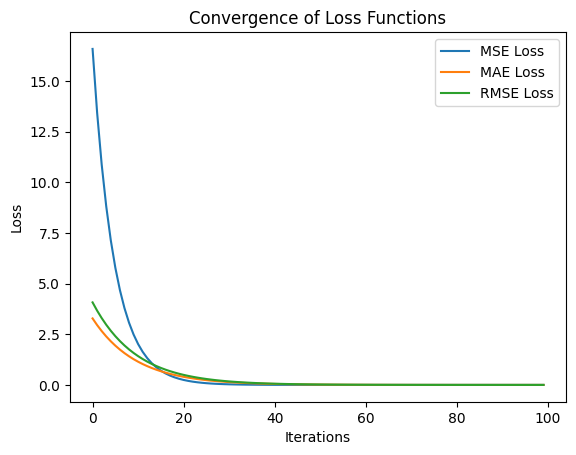

In [21]:
# 4. Effect of Loss Functions on Convergence
# For simplicity, we will simulate convergence by plotting the loss values over iterations for a simple linear regression model.
# In practice, you would implement gradient descent to see the actual convergence behavior.
def simulate_convergence(loss_func, y_true, y_pred, iterations=100):
    losses = []
    for i in range(iterations):
        # Simulate predictions improving over time
        y_pred = y_pred + (y_true - y_pred) * 0.1  # Simulate gradient descent step
        loss = loss_func(y_true, y_pred)
        losses.append(loss)
    return losses
# Simulate convergence for MSE and MAE
y = 2 * X.squeeze() + 1 + np.random.randn(100) * 5  # Linear relation with noise
y_pred = 2 * X.squeeze() + 1  # Start with perfect linear model
mse_losses = simulate_convergence(mse, y, y_pred)
mae_losses = simulate_convergence(mae, y, y_pred)
rmse_losses = simulate_convergence(rmse, y, y_pred)
# Plot convergence
plt.plot(mse_losses, label='MSE Loss')
plt.plot(mae_losses, label='MAE Loss')
plt.plot(rmse_losses, label='RMSE Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Convergence of Loss Functions')
plt.legend()
plt.show()

##### 5. Choosing the Appropriate Loss Function
The choice of loss function depends on the problem at hand:
 - For regression tasks, MSE is commonly used when you want to penalize larger errors more heavily, while MAE is more robust to outliers.
 - For classification tasks, cross-entropy loss is typically used as it measures the performance of a classification model whose output is a probability value between 0 and 1.
